# SEM Dendrites - 01_explore (Dataset inspection)

**Goal:** Understand the SEM dataset properties before building the segmentation pipelines.  
In this notebook we:
- Load one **easy** and one **hard** TIFF image
- Inspect dtype and intensity range
- Normalize to 8-bit (0-255)
- Remove the bottom scale bar / text by cropping
- Compare easy vs hard visually

**Next:** Build the full classical pipeline in `02_classic_pipeline.ipynb`.

## 1. Load raw TIFF images and inspect basic statistics

We load one representative image from each subset and print:
- image dtype (bit depth)
- shape
- min/max intensity values

This tells us whether normalization is required before using OpenCV-based processing.

In [10]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt

easy_path = "data/easy/Ag_1e-8_009.tif"
hard_path = "data/hard/70nm_R_50nm_pitch_ETD_005.tif"

easy = io.imread(easy_path)
hard = io.imread(hard_path)

print("EASY:", easy.dtype, easy.shape, easy.min(), easy.max())
print("HARD:", hard.dtype, hard.shape, hard.min(), hard.max())

EASY: uint16 (1094, 1536) 10225 65535
HARD: uint16 (1094, 1536) 6035 65535


**Observation:** The images are grayscale TIFFs with a wide intensity range (16-bit).  
**Implication:** We must normalize intensities before applying thresholding and other processing steps.

## 2. Normalize to 8-bit (0-255)

Many algorithms expect 8-bit images.  
We apply min-max normalization per image to convert the pixel range to 0-255 (`uint8`).

In [11]:
def to_uint8(img):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return (img * 255).astype(np.uint8)

easy8 = to_uint8(easy)
hard8 = to_uint8(hard)

**Observation:** After normalization, both images share a comparable scale (0-255).  
**Implication:** Later thresholding and filtering steps can use consistent parameter ranges.

## 3. Bottom Overlay Height Estimation (Row Intensity Analysis)

Before removing the bottom overlay (scale bar and text), 
we estimate its height by analyzing the mean pixel intensity per image row.

The overlay region differs significantly in brightness compared to the SEM background.
Therefore, a noticeable transition is expected in the row-wise intensity profile.

By plotting the mean intensity per row, we identify a sharp change near the bottom,
which corresponds to the beginning of the overlay region.

Image height: 1094


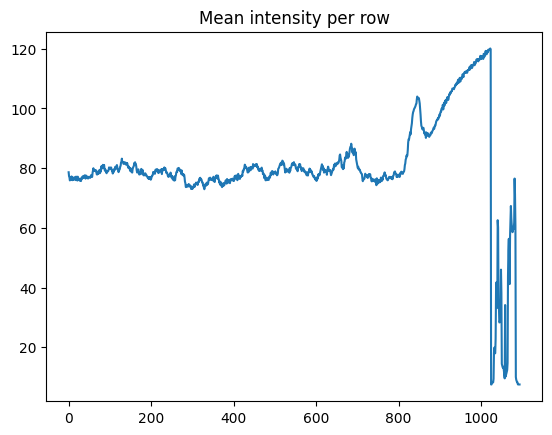

In [31]:
row_means = easy8.mean(axis=1)
h = easy8.shape[0]
print("Image height:", h)
plt.plot(row_means)
plt.title("Mean intensity per row")
plt.show()

**Estimated overlay height:** 1094 - 1000 = 94

## 3. Remove bottom scale bar / text (artifact removal)

The SEM images include a bottom overlay (scale bar and text).  
We remove it using a fixed crop ratio so it will not be mistakenly detected as part of the dendrite structure.

Original shapes: (1094, 1536) (1094, 1536)
Cropped shapes: (1017, 1536) (1017, 1536)


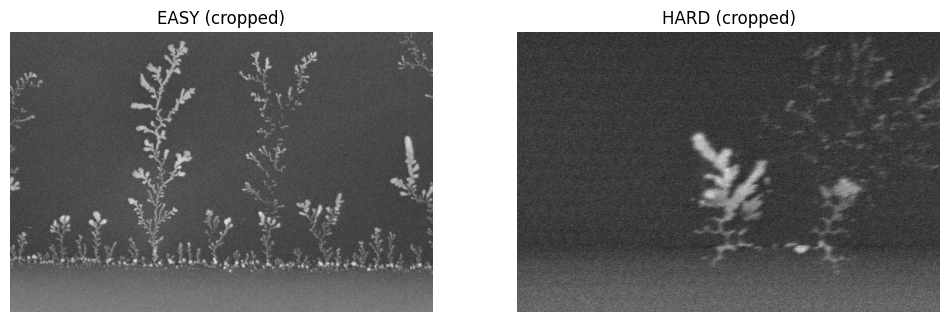

In [33]:
def crop_scale_bar(img8, crop_ratio=0.93):
    h, w = img8.shape
    return img8[:int(h*crop_ratio), :]

easy_c = crop_scale_bar(easy8, 0.93)
hard_c = crop_scale_bar(hard8, 0.93)
print("Original shapes:", easy8.shape, hard8.shape)
print("Cropped shapes:", easy_c.shape, hard_c.shape)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(easy_c, cmap="gray")
plt.title("EASY (cropped)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hard_c, cmap="gray")
plt.title("HARD (cropped)")
plt.axis("off")

plt.show()

After some experimentation, we concluded that 93 pixels is the optimal value for cropping.

## 4. Easy vs Hard - qualitative comparison
**Key differences:**
- **Easy:** higher contrast and clearer dendritic structures.
- **Hard:** lower contrast and more background noise / non-uniformity.

**Project implication:** The segmentation pipeline must be robust enough to handle the **Hard** subset.

## 5. Exploration summary

1. The dataset requires **per-image normalization** to 8-bit.
2. The bottom scale bar/text is an **artifact** and must be removed (cropping works).
3. The **Hard** subset is visually more challenging (lower contrast + higher noise).

**Next notebook:** `02_classic_pipeline.ipynb` - build the classical segmentation pipeline end-to-end.